# **1-Import Main Libraries & Parameters**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0 , resnet50 ,mobilenet_v2
from tensorflow.keras.layers import Dropout , Dense , BatchNormalization , ReLU
from tensorflow.keras import models, layers, optimizers, callbacks, preprocessing, applications,Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from warnings import filterwarnings
filterwarnings("ignore")
import os
import json
import cv2
import re
import textwrap
IMG_SIZE = 224
BATCH_SIZE = 32
MAX_TOKENS = 5000
MAX_LEN = 25

# **2-Prepare Dataset to Dataframe**

In [2]:
def coco_to_dataframe(image_dir, annotation_file):
    with open(annotation_file, "r", encoding="utf-8") as f:
        coco = json.load(f)
    id_to_file = {img["id"]: img["file_name"] for img in coco["images"]}

    data = []

    for ann in coco["annotations"]:
        image_id = ann["image_id"]
        caption = ann["caption"]

        file_name = id_to_file[image_id]
        image_path = os.path.join(image_dir, file_name)

        data.append({
            "image_path": image_path,
            "caption": caption
        })

    df = pd.DataFrame(data)
    return df

In [3]:
df = coco_to_dataframe("/kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/val2017",
                       "/kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/annotations/captions_val2017.json")
print("Sample path:")
print()
print(df["image_path"].iloc[1])
print(df["caption"].iloc[1])
print()
print("----------------------")
print()
print("Unique images:", df["image_path"].nunique())
print()
print("----------------------")
df.head()

Sample path:

/kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/val2017/000000179765.jpg
A Honda motorcycle parked in a grass driveway

----------------------

Unique images: 5000

----------------------


,image_path,caption
0,/kaggle/input/datasets/awsaf49/coco-2017-datas...,A black Honda motorcycle parked in front of a ...
1,/kaggle/input/datasets/awsaf49/coco-2017-datas...,A Honda motorcycle parked in a grass driveway
2,/kaggle/input/datasets/awsaf49/coco-2017-datas...,An office cubicle with four different types of...
3,/kaggle/input/datasets/awsaf49/coco-2017-datas...,A small closed toilet in a cramped space.
4,/kaggle/input/datasets/awsaf49/coco-2017-datas...,Two women waiting at a bench next to a street.


# **3-Visualization For Data Samples**

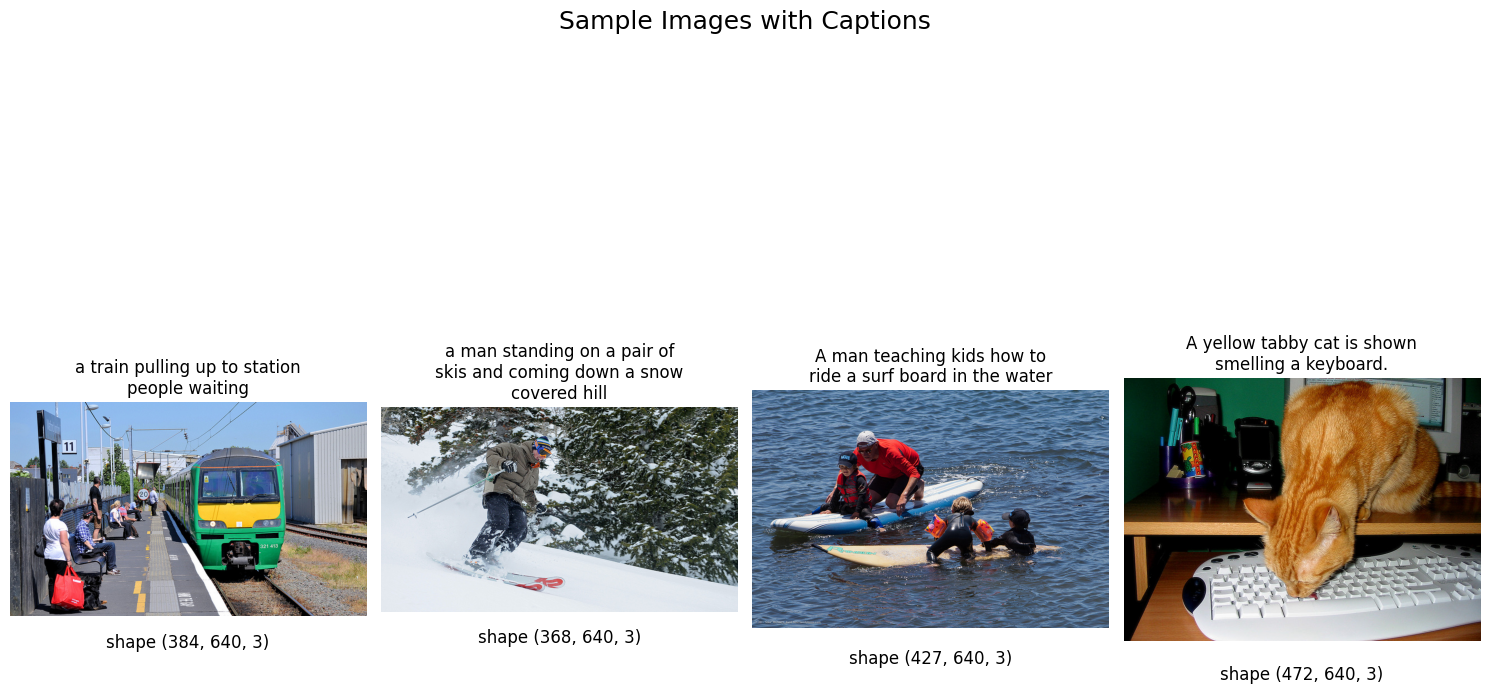

In [4]:
import textwrap

plt.figure(figsize=(15, 10))

num_samples = 4
sample_df = df.sample(num_samples, random_state=101)

cols = 4
rows = 1

for i, (_, row) in enumerate(sample_df.iterrows()):
    img_path = row['image_path']
    caption = row['caption']

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    caption = "\n".join(textwrap.wrap(caption, width=30))

    plt.subplot(1, cols, i + 1)
    plt.imshow(img)
    plt.title(caption, fontsize=12)
    plt.text(0.5, -0.15, f"shape {img.shape}",
             fontsize=12,
             ha='center',
             transform=plt.gca().transAxes)
    plt.axis('off')

plt.suptitle("Sample Images with Captions", fontsize=18)
plt.tight_layout()
plt.show()

# **4-Splliting Data**

In [5]:
unique_images = df["image_path"].unique()

train_imgs, val_imgs = train_test_split(
    unique_images,
    test_size=0.2,
    random_state=42
)

train_df = df[df["image_path"].isin(train_imgs)].reset_index(drop=True)
val_df = df[df["image_path"].isin(val_imgs)].reset_index(drop=True)

print("Train rows:", len(train_df))
print("Val rows:", len(val_df))
print("------------------------")
print("Train unique images:", train_df["image_path"].nunique())
print("Val unique images:", val_df["image_path"].nunique())

Train rows: 20012
Val rows: 5002
------------------------
Train unique images: 4000
Val unique images: 1000


# **5-Captions Cleaning**

In [6]:
def caption_cleaning(df):
    df = df.copy()

    def clean(text):
        text = str(text).lower().strip()
        text = re.sub(r"[^a-z ]", "", text)
        text = re.sub(r"\s+", " ", text)
        text = text.strip()
        return f"<start> {text} <end>"

    df["caption"] = df["caption"].apply(clean)
    return df


# apply
print("Applying start/end tokens:")
train_df = caption_cleaning(train_df)
val_df = caption_cleaning(val_df)

print(train_df["caption"].iloc[0])

Applying start/end tokens:
<start> a black honda motorcycle parked in front of a garage <end>


# **6-Victorize Captions**

In [7]:
def build_vectorizer(train_captions, max_tokens=MAX_TOKENS, max_len=MAX_LEN):
    vectorizer = tf.keras.layers.TextVectorization(
        max_tokens=max_tokens,
        output_mode="int",
        output_sequence_length=max_len,
        standardize=None
    )
    vectorizer.adapt(train_captions)
    return vectorizer

vectorizer = build_vectorizer(
    train_df["caption"].values,
    max_tokens=MAX_TOKENS,
    max_len=MAX_LEN
)
sample_caption = train_df["caption"].iloc[0]

print("Original:")
print(sample_caption)

print("\nVectorized:")
print(vectorizer([sample_caption]))

Original:
<start> a black honda motorcycle parked in front of a garage <end>

Vectorized:
tf.Tensor(
[[   3    2   44 2675  133   73    8   42    6    2 1028    4    0    0
     0    0    0    0    0    0    0    0    0    0    0]], shape=(1, 25), dtype=int64)


2026-04-20 12:50:45.351156: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


# 7-Preparing Images And Dataset for Model

In [ ]:
def preprocess_image(path):
    img = tf.io.read_file(path)
    img = tf.io.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = tf.keras.applications.efficientnet.preprocess_input(img)
    return img

In [ ]:
def make_dataset(df, vectorizer, batch_size=BATCH_SIZE, shuffle=True):
    image_paths = df["image_path"].values
    captions = df["caption"].values

    ds = tf.data.Dataset.from_tensor_slices((image_paths, captions))

    if shuffle:
        ds = ds.shuffle(2000, reshuffle_each_iteration=True)

    def process(path, caption):
        img = preprocess_image(path)

        seq = vectorizer(caption)  # shape = (MAX_LEN,)
        decoder_input = seq[:-1]   # shape = (MAX_LEN-1,)
        target = seq[1:]           # shape = (MAX_LEN-1,)

        # ignore padding tokens in loss/metrics
        sample_weight = tf.cast(target != 0, tf.float32)

        return (img, decoder_input), target, sample_weight

    ds = ds.map(process, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_dataset(
        train_df,
        vectorizer,
        batch_size=BATCH_SIZE,
        shuffle=True)

val_ds = make_dataset(
        val_df,
        vectorizer,
        batch_size=BATCH_SIZE,
        shuffle=False)

In [10]:
for (imgs, dec_in), y in train_ds.take(1):
    print(imgs.shape)
    print(dec_in.shape)
    print(y.shape)

(32, 224, 224, 3)
(32, 24)
(32, 24)


# **8-CNN Model ENCODER Architecture**

In [ ]:
base_cnn =EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    pooling="max"
)

base_cnn.trainable = False

image_input = tf.keras.layers.Input(shape=(224, 224, 3), name="image_input")
x = base_cnn(image_input)
x = Dense(256, name="img_dense")(x)
x = BatchNormalization()(x)
x = ReLU()(x)
x = Dropout(0.2, name="img_dropout")(x)

cnn_model = Model(inputs=image_input, outputs=x, name="cnn_branch")



cnn_model.summary()


Model: "cnn_branch"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image_input (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 1280)           │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ img_dense (Dense)               │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ img_dropout (Dropout)           │ (None, 256)            │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,378,531 (16.70 MB)

 Trainable params: 4,335,996 (16.54 MB)

 Non-trainable params: 42,535 (166.16 KB)

# **9-RNN Model Architecture**

In [ ]:
vocab = vectorizer.get_vocabulary()
VOCAB_SIZE = len(vocab)

print("Vocabulary size:", VOCAB_SIZE)
print("MAX_LEN:", MAX_LEN)


image_input = tf.keras.layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name="image_input")
text_input  = tf.keras.layers.Input(shape=(MAX_LEN - 1,), name="decoder_input")

img_feat = cnn_model(image_input)

if len(img_feat.shape) == 4:
    img_feat = tf.keras.layers.GlobalAveragePooling2D()(img_feat)

img_feat = tf.keras.layers.Dense(256, activation="relu")(img_feat)
img_feat = tf.keras.layers.Dropout(0.2)(img_feat)

img_context = tf.keras.layers.RepeatVector(MAX_LEN - 1)(img_feat)

x = tf.keras.layers.Embedding(
    input_dim=VOCAB_SIZE,
    output_dim=256,
    mask_zero=False,   
    name="token_embedding"
)(text_input)

x = tf.keras.layers.Dropout(0.2)(x)

x = tf.keras.layers.Concatenate(axis=-1)([x, img_context])

x = tf.keras.layers.LSTM(256, return_sequences=True, dropout=0.2)(x)
x = tf.keras.layers.LayerNormalization()(x)

x = tf.keras.layers.LSTM(256, return_sequences=True, dropout=0.2)(x)
x = tf.keras.layers.LayerNormalization()(x)

x = tf.keras.layers.Dense(256, activation="relu")(x)
x = tf.keras.layers.Dropout(0.3)(x)

output = tf.keras.layers.Dense(VOCAB_SIZE, activation="softmax", name="word_output")(x)

caption_model = tf.keras.Model(
    inputs=[image_input, text_input],
    outputs=output,
    name="cnn_rnn_caption_model"
)

caption_model.summary()

# **10-Compiling Model & Callbacks**

In [ ]:
caption_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    weighted_metrics=["sparse_categorical_accuracy"]
)

In [ ]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_sparse_categorical_accuracy",
    patience=3,
    mode="max",
    restore_best_weights=True,
    verbose=1
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "best_Model_caption.keras",
    monitor="val_sparse_categorical_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

callbacks_list = [early_stop, reduce_lr, checkpoint]

# **11- Train Model**

In [ ]:
history = caption_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=callbacks_list,
    verbose=1
)

# **12-Fine-Tune Last Layers of CNN**

In [ ]:
cnn_model.trainable = True

for layer in cnn_model.layers[:-20]:
    layer.trainable = False

caption_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    weighted_metrics=["sparse_categorical_accuracy"]
)

history_ft = caption_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=8,
    callbacks=callbacks_list,
    verbose=1
)

# **13-Evaluate Model**

In [ ]:
results = caption_model.evaluate(val_ds, verbose=1)

print("\nValidation Loss     :", results[0])
print("Validation Accuracy :", results[1])

# **14-Visualize Training Performance**

In [ ]:
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
full_acc = history.history['accuracy']
test_acc = history.history['val_accuracy']

train_loss = history_ft.history['loss']
val_loss = history_ft.history['val_loss']
full_loss = history_ft.history['loss']
test_loss = history_ft.history['val_loss']


epochs_train_val = range(1, len(train_acc)+1)
epochs_full = range(len(train_acc)+1, len(train_acc)+len(full_acc)+1)

plt.figure(figsize=(14,5))


plt.subplot(1,2,1)
plt.plot(epochs_train_val, train_acc, label='Train Accuracy')
plt.plot(epochs_train_val, val_acc, label='Val Accuracy')
plt.plot(epochs_full, full_acc, label='Full Training Accuracy')
plt.plot(epochs_full, test_acc, label='Test Accuracy')
plt.title('Training + Fine-Tuning Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)


plt.subplot(1,2,2)
plt.plot(epochs_train_val, train_loss, label='Train Loss')
plt.plot(epochs_train_val, val_loss, label='Val Loss')
plt.plot(epochs_full, full_loss, label='Full Training Loss')
plt.plot(epochs_full, test_loss, label='Test Loss')
plt.title('Training + Fine-Tuning Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# **15-Prepare Vocabulary Helper**

In [ ]:
idx_to_word = np.array(vectorizer.get_vocabulary())
word_to_idx = {word: i for i, word in enumerate(idx_to_word)}

print("Sample vocab:", idx_to_word[:20])

In [ ]:
start_token = word_to_idx.get("<start>", None)
end_token   = word_to_idx.get("<end>", None)

print("start_token:", start_token)
print("end_token  :", end_token)

# **16-Greedy Caption Generation**

In [ ]:
def generate_caption(image_path, model, max_len=MAX_LEN):
    img = preprocess_image(tf.constant(image_path))
    img = tf.expand_dims(img, axis=0)

    decoded = []

    if start_token is not None:
        decoded.append(start_token)

    for _ in range(max_len - 1):
        padded = tf.keras.preprocessing.sequence.pad_sequences(
            [decoded], maxlen=max_len - 1, padding="post"
        )

        preds = model.predict([img, padded], verbose=0)
        step_index = max(len(decoded) - 1, 0)
        next_token = int(np.argmax(preds[0, step_index]))

        if next_token == 0:
            break
        if end_token is not None and next_token == end_token:
            break

        decoded.append(next_token)

    words = []
    for token_id in decoded:
        if token_id == 0:
            continue
        if start_token is not None and token_id == start_token:
            continue
        if end_token is not None and token_id == end_token:
            continue

        word = idx_to_word[token_id]
        if word not in ["<start>", "<end>"]:
            words.append(word)

    return " ".join(words)

# **17-Visualize Predicted Captions**

In [ ]:
sample_vis_df = val_df.sample(4, random_state=42).reset_index(drop=True)

plt.figure(figsize=(18, 10))

for i, row in sample_vis_df.iterrows():
    img_path = row["image_path"]
    true_caption = row["caption"]
    pred_caption = generate_caption(img_path, caption_model)

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    true_caption = true_caption.replace("<start>", "").replace("<end>", "").strip()

    title_text = f"True: {true_caption}\nPred: {pred_caption}"
    title_text = "\n".join(textwrap.wrap(title_text, width=45))

    plt.subplot(2, 2, i + 1)
    plt.imshow(img)
    plt.title(title_text, fontsize=10)
    plt.axis("off")

plt.tight_layout()
plt.show()

# **18-Test On Random Example**

In [ ]:
random_row = val_df.sample(1).iloc[0]

img_path = random_row["image_path"]
true_caption = random_row["caption"].replace("<start>", "").replace("<end>", "").strip()
pred_caption = generate_caption(img_path, caption_model)

img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8, 8))
plt.imshow(img)
plt.title(f"True: {true_caption}\nPred: {pred_caption}", fontsize=12)
plt.axis("off")
plt.show()